# Olist Revenue Leakage - Machine Learning Modeling
This notebook builds a classification pipeline (using XGBoost) to predict high leakage risk and an anomaly detection model (using Isolation Forest) to flag outliers in the transaction features. The final models are serialized for use in the Streamlit web application.

In [1]:
import pandas as pd
import numpy as np
import pickle
import os
import joblib

df = pd.read_csv("../data/processed_fact_orders.csv", parse_dates=["order_purchase_timestamp"])
print("Loaded data shape:", df.shape)

Loaded data shape: (99441, 35)


## Define Target
Define target as orders with leakage above the 75th percentile of non-zero leakage (or 75th percentile of the total population).

In [2]:
df["target_high_leakage"] = (df["leakage_amount"] > df["leakage_amount"].quantile(0.75)).astype(int)
print("Class distribution:\n", df["target_high_leakage"].value_counts(normalize=True))

Class distribution:
 target_high_leakage
0    0.750033
1    0.249967
Name: proportion, dtype: float64


## Data Transformation Pipeline

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

numeric_features = ["total_price", "total_freight", "freight_ratio", "installments", "delay_days"]
categorical_features = ["payment_type", "product_category_name_english"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

## Train/Test Split

In [4]:
from sklearn.model_selection import train_test_split

X = df[numeric_features + categorical_features]
y = df["target_high_leakage"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training set shape: {X_train.shape}, Test set shape: {X_test.shape}")

Training set shape: (79552, 7), Test set shape: (19889, 7)


## Preprocessing + XGBoost Model Pipeline

In [5]:
from xgboost import XGBClassifier

model_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        eval_metric="logloss", random_state=42
    ))
])

print("Training XGBoost classifier...")
model_pipeline.fit(X_train, y_train)
print("Training complete.")

Training XGBoost classifier...
Training complete.


## Model Evaluation

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.99      0.95     14917
           1       0.97      0.73      0.83      4972

    accuracy                           0.93     19889
   macro avg       0.94      0.86      0.89     19889
weighted avg       0.93      0.93      0.92     19889

ROC-AUC: 0.9136521697884097


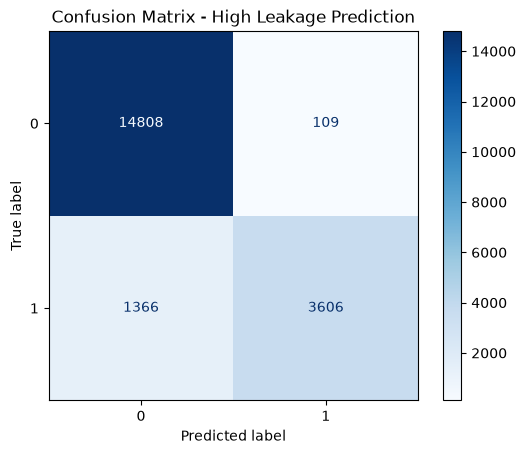

In [6]:
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = model_pipeline.predict(X_test)
y_proba = model_pipeline.predict_proba(X_test)[:, 1]

print("Classification Report:")
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")
plt.title("Confusion Matrix - High Leakage Prediction")
plt.grid(False)
plt.show()

## Feature Importance

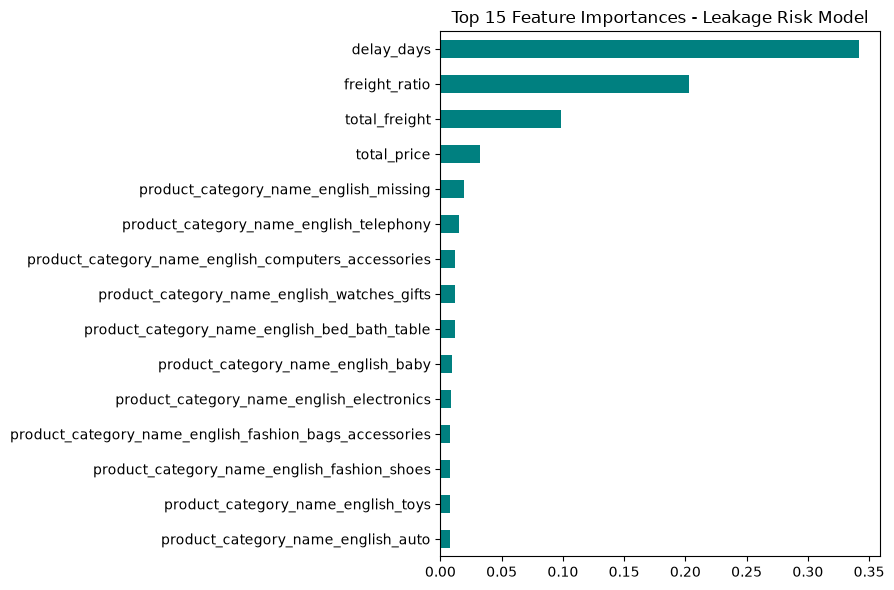

In [7]:
ohe_cols = list(model_pipeline.named_steps["preprocessor"]
                .named_transformers_["cat"]
                .named_steps["onehot"]
                .get_feature_names_out(categorical_features))

all_feature_names = numeric_features + ohe_cols

importances = model_pipeline.named_steps["classifier"].feature_importances_
importance_df = pd.Series(importances, index=all_feature_names).sort_values(ascending=False).head(15)

plt.figure(figsize=(9,6))
importance_df.plot(kind="barh", color="teal")
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances - Leakage Risk Model")
plt.tight_layout()
plt.show()

## Anomaly Detection Model

In [8]:
from sklearn.ensemble import IsolationForest

anomaly_features = df[["total_price", "total_freight", "freight_ratio", "delay_days"]].fillna(0)

anomaly_model = IsolationForest(contamination=0.05, random_state=42)
print("Training Isolation Forest anomaly detector...")
anomaly_model.fit(anomaly_features)

df["is_anomaly"] = anomaly_model.predict(anomaly_features) == -1
print("Anomaly Counts (True = Anomaly):")
print(df["is_anomaly"].value_counts())

Training Isolation Forest anomaly detector...
Anomaly Counts (True = Anomaly):
is_anomaly
False    94469
True      4972
Name: count, dtype: int64


## Export Serialized Models

In [9]:
os.makedirs("../ml/models", exist_ok=True)

# 1. Save classification pipeline (bundles preprocessing + XGBoost)
with open("../ml/models/leakage_classifier_pipeline.pkl", "wb") as f:
    pickle.dump(model_pipeline, f)

# 2. Save anomaly detector
with open("../ml/models/anomaly_detector.pkl", "wb") as f:
    pickle.dump(anomaly_model, f)

# 3. Save feature config details for Streamlit drop-down lists
with open("../ml/models/feature_config.pkl", "wb") as f:
    pickle.dump({
        "numeric_features": numeric_features,
        "categorical_features": categorical_features,
        "category_options": {
            "payment_type": df["payment_type"].dropna().unique().tolist(),
            "product_category_name_english": df["product_category_name_english"].dropna().unique().tolist()
        }
    }, f)

print("All models and configuration files saved successfully.")

All models and configuration files saved successfully.
